In [1]:
from pathlib import Path
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

In [52]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as f 
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

In [3]:
def get_spark():
    return SparkSession.builder \
        .appName('TCC - Testes') \
        .getOrCreate()

spark = get_spark()

In [9]:
df = spark.read.parquet('../data/criminalidade/curated/veiculos_setor_parquet')
df_crimes = df.filter(df.nome_municipio == "S.PAULO")
df.show(5, False)

+------------+--------------------+--------------------+--------------+------+-------+------+----------------------+-------------------+------------------------+-------------------+------------------+---------------+----------------------+-------------------+----------------------+------------+--------------+-----------+----------------+-------------+-------------------------------+------------------+------------+-------+-------------------+-----------------------------------------+-----------------+-----------------+-----------------+------------+------------------------+------------------+--------------------+--------------+----------+-------------+-----------------+---------------+---------------+-------------------+-----------+-----------------+-----------------+----------------------------+----------------------+-------------------+-------------+--------+--------+-----------+---------------+-----------+---------+----------+-----------------+------------+------------+--------+-----

In [10]:
df_censo_final = spark.read.parquet('../data/censo/final/processed/setor')
df_censo = df_censo_final.filter(df_censo_final.nm_mun == 'São Paulo')
df_censo.show(5, False)

+---------------+---------+---------+-----------+-----------+-----------+-------+--------------------+-------+---------+---------+----------+-------------+----------------------------------+--------------------------------+----------------------+--------------------+----------------------+-------------------+--------------------------------------------+------------------+------------------+---------------------+-------------------+-----------+----------+--------------------+-------------------+-------------------+----------------------------+---------------------------------------+-----------------------------------------+-------------------------------------------+------------------------------------+-----------------+-----------------+--------------------------+----------------------------+-------------------------+---------------------------+----------------------------+------------------------+----------------------+-----------------------------+
|cd_setor       |cd_dist  |nm_dist 

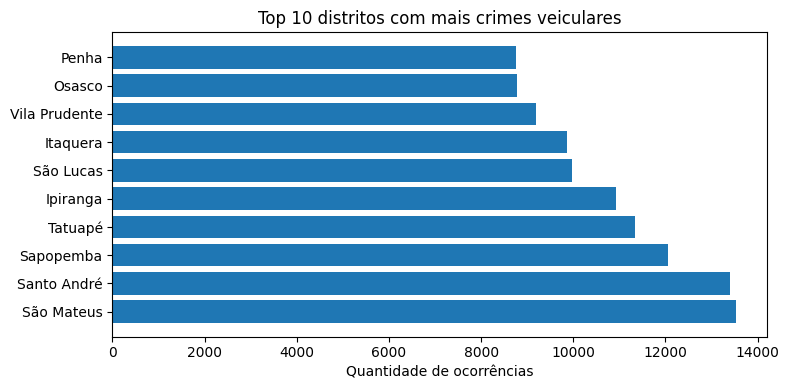

In [32]:
resultado = spark.sql("""
    select  SJ_NM_DIST,
            COUNT(*) AS total_crimes
    from    crimes
    where   SJ_CD_SETOR IS NOT NULL
            and (
                is_roubo = True or is_furto = True
            )
    group by 1
    order by 2 desc
    limit 10
""")

pdf = resultado.toPandas()

plt.figure(figsize=(8,4))
plt.barh(
    pdf["SJ_NM_DIST"],
    pdf["total_crimes"]
)

plt.title("Top 10 distritos com mais crimes veiculares")
plt.xlabel("Quantidade de ocorrências")
plt.tight_layout()
plt.show()

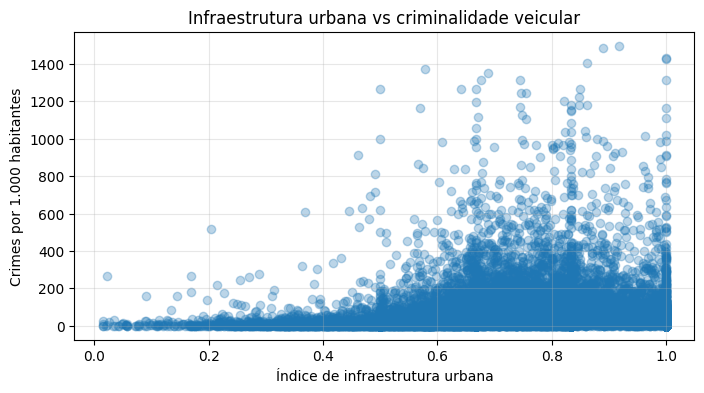

In [47]:
pdf = spark.sql("""
    SELECT
        indice_infraestrutura_urbana,
        tx_crimes_1000_hab
    FROM analise
    WHERE indice_infraestrutura_urbana IS NOT NULL
      AND tx_crimes_1000_hab IS NOT NULL
    and tx_crimes_1000_hab < 1500
""").toPandas()

plt.figure(figsize=(8,4))

plt.scatter(
    pdf["indice_infraestrutura_urbana"],
    pdf["tx_crimes_1000_hab"],
    alpha=0.3
)

plt.xlabel("Índice de infraestrutura urbana")
plt.ylabel("Crimes por 1.000 habitantes")
plt.title("Infraestrutura urbana vs criminalidade veicular")

plt.grid(alpha=0.3)
plt.show()

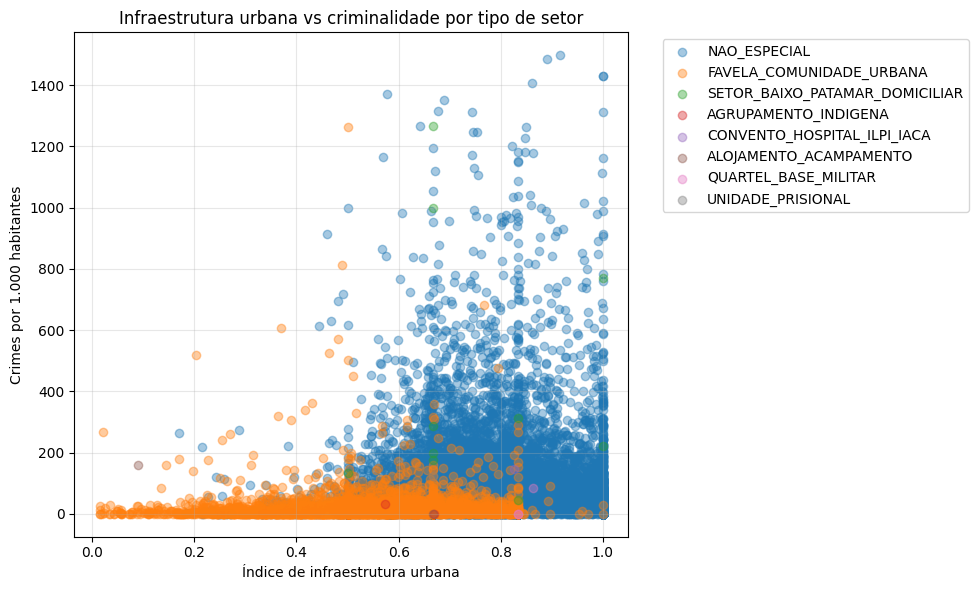

In [74]:
pdf = spark.sql("""
    SELECT
        indice_infraestrutura_urbana,
        tx_crimes_1000_hab,
        categoria_tipo_setor
    FROM analise
    WHERE indice_infraestrutura_urbana IS NOT NULL
      AND tx_crimes_1000_hab IS NOT NULL
      AND categoria_tipo_setor IS NOT NULL
      and tx_crimes_1000_hab < 1500
      -- and (is_furto = True or is_roubo = True)
""").toPandas()

plt.figure(figsize=(10,6))

for tipo in pdf["categoria_tipo_setor"].unique():

    dados = pdf[
        pdf["categoria_tipo_setor"] == tipo
    ]

    plt.scatter(
        dados["indice_infraestrutura_urbana"],
        dados["tx_crimes_1000_hab"],
        alpha=0.4,
        label=tipo
    )

plt.xlabel("Índice de infraestrutura urbana")
plt.ylabel("Crimes por 1.000 habitantes")
plt.title("Infraestrutura urbana vs criminalidade por tipo de setor")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [70]:
variaveis = [
    "tx_via_pavimentada",
    "tx_bueiro",
    "tx_iluminacao_publica",
    "tx_ponto_onibus",
    "tx_ciclovia",
    "tx_calcada",
    "tx_obstaculo_calcada",
    "tx_rampa_cadeirante",
    "tx_arborizacao"
]

resultado = []

for var in variaveis:

    corr = spark.sql(f"""
        SELECT corr(
            {var},
            tx_crimes_1000_hab
        ) AS correlacao
        FROM analise
        WHERE {var} IS NOT NULL
          AND tx_crimes_1000_hab IS NOT NULL
           -- and categoria_tipo_setor not like '%FAVELA%'
          and tx_crimes_1000_hab < 1500
    """).first()["correlacao"]

    resultado.append((var, corr))

pdf_corr = pd.DataFrame(
    resultado,
    columns=["variavel", "correlacao"]
)

pdf_corr.sort_values(
    "correlacao",
    ascending=False,
    inplace=True
)

pdf_corr

,variavel,correlacao
5,tx_calcada,0.108120
7,tx_rampa_cadeirante,0.096733
2,tx_iluminacao_publica,0.070532
8,tx_arborizacao,0.065623
0,tx_via_pavimentada,0.054759
1,tx_bueiro,0.036023
3,tx_ponto_onibus,0.032548
6,tx_obstaculo_calcada,0.016901
4,tx_ciclovia,0.008162


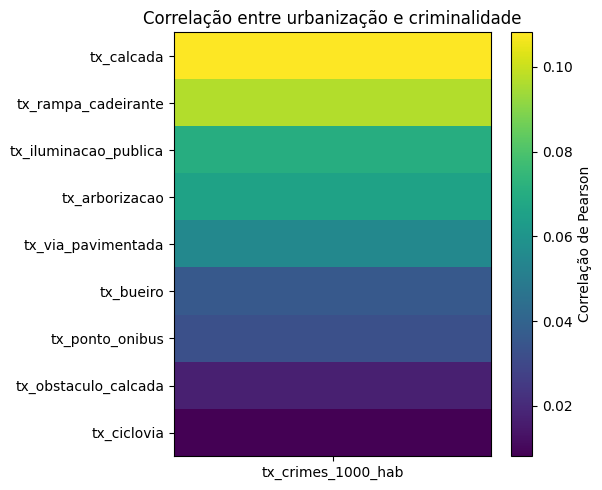

In [71]:
dados = pdf_corr.set_index("variavel")

plt.figure(figsize=(6,5))

plt.imshow(
    dados,
    aspect="auto"
)

plt.colorbar(label="Correlação de Pearson")

plt.yticks(
    np.arange(len(dados.index)),
    dados.index
)

plt.xticks([0], ["tx_crimes_1000_hab"])

plt.title(
    "Correlação entre urbanização e criminalidade"
)

plt.tight_layout()
plt.show()

In [82]:
crimes_filtrados_setor = spark.sql("""
    SELECT
        SJ_CD_SETOR AS cd_setor,
        COUNT(*) AS total_crimes
    FROM crimes
    WHERE SJ_CD_SETOR IS NOT NULL
      AND (is_furto = TRUE)
    GROUP BY SJ_CD_SETOR
""")

crimes_filtrados_setor.createOrReplaceTempView("crimes_filtrados_setor")

analise_filtrada = spark.sql("""
    SELECT
        c.cd_setor,
        c.total_crimes,
        d.qt_pessoas,

        d.tx_via_pavimentada,
        d.tx_bueiro,
        d.tx_iluminacao_publica,
        d.tx_ponto_onibus,
        d.tx_ciclovia,
        d.tx_calcada,
        d.tx_obstaculo_calcada,
        d.tx_rampa_cadeirante,
        d.tx_arborizacao,
        d.categoria_tipo_setor,

        CASE
            WHEN d.qt_pessoas > 0
            THEN (c.total_crimes / d.qt_pessoas) * 1000
            ELSE NULL
        END AS tx_crimes_1000_hab

    FROM crimes_filtrados_setor c
    INNER JOIN censo d
        ON c.cd_setor = d.cd_setor
""")

analise_filtrada.createOrReplaceTempView("analise_filtrada")
resultado = []

for var in variaveis:

    corr = spark.sql(f"""
        SELECT corr(
            {var},
            tx_crimes_1000_hab
        ) AS correlacao
        FROM analise_filtrada
        WHERE {var} IS NOT NULL
          AND tx_crimes_1000_hab IS NOT NULL
          AND tx_crimes_1000_hab < 1500
          -- AND categoria_tipo_setor NOT LIKE '%FAVELA%'
    """).first()["correlacao"]

    resultado.append((var, corr))

pdf_corr = pd.DataFrame(
    resultado,
    columns=["variavel", "correlacao"]
)

pdf_corr.sort_values(
    "correlacao",
    ascending=False,
    inplace=True
)

pdf_corr

,variavel,correlacao
7,tx_rampa_cadeirante,0.189808
8,tx_arborizacao,0.084309
5,tx_calcada,0.079673
1,tx_bueiro,0.053392
4,tx_ciclovia,0.043744
2,tx_iluminacao_publica,0.043607
3,tx_ponto_onibus,0.039527
0,tx_via_pavimentada,0.033759
6,tx_obstaculo_calcada,-0.096987


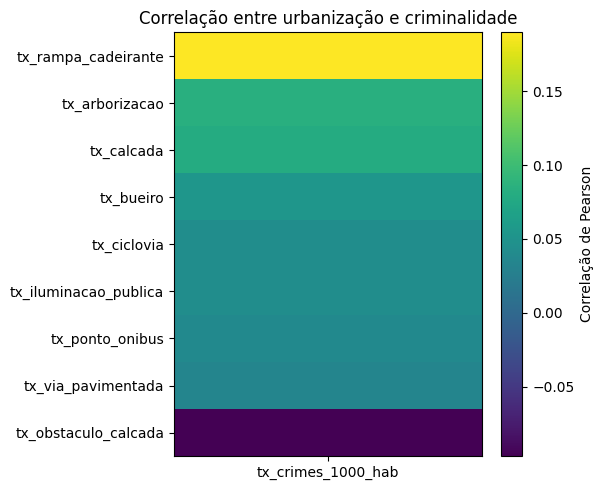

In [83]:
dados = pdf_corr.set_index("variavel")

plt.figure(figsize=(6,5))

plt.imshow(
    dados,
    aspect="auto"
)

plt.colorbar(label="Correlação de Pearson")

plt.yticks(
    np.arange(len(dados.index)),
    dados.index
)

plt.xticks([0], ["tx_crimes_1000_hab"])

plt.title(
    "Correlação entre urbanização e criminalidade"
)

plt.tight_layout()
plt.show()

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# variaveis_urbanas = [
#     "tx_via_pavimentada",
#     "tx_bueiro",
#     "tx_iluminacao_publica",
#     "tx_ponto_onibus",
#     "tx_ciclovia",
#     "tx_calcada",
#     "tx_obstaculo_calcada",
#     "tx_rampa_cadeirante",
#     "tx_arborizacao"
# ]

variaveis_urbanas = [
    "densidade_populacional",
    "densidade_domicilios",
    "log_renda_media",
    "log_renda_mediana",
    "indice_infraestrutura_urbana",
    "indice_mobilidade_urbana",
    "indice_vulnerabilidade_urbana",
    "tx_iluminacao_publica",
    "tx_arborizacao",
    "tx_calcada"
]

def calcular_correlacoes(nome_view, filtro_sql="1=1"):
    resultado = []

    for var in variaveis_urbanas:
        corr = spark.sql(f"""
            SELECT corr({var}, tx_crimes_1000_hab) AS correlacao
            FROM {nome_view}
            WHERE {filtro_sql}
              AND {var} IS NOT NULL
              AND tx_crimes_1000_hab IS NOT NULL
        """).first()["correlacao"]

        resultado.append((var, corr))

    pdf_corr = pd.DataFrame(
        resultado,
        columns=["variavel", "correlacao"]
    )

    pdf_corr["correlacao"] = pd.to_numeric(
        pdf_corr["correlacao"],
        errors="coerce"
    )

    pdf_corr = pdf_corr.dropna()

    return pdf_corr.sort_values("correlacao")


def plotar_correlacoes(pdf_corr, titulo):
    plt.figure(figsize=(8,4))

    plt.barh(
        pdf_corr["variavel"],
        pdf_corr["correlacao"]
    )

    plt.axvline(
        0,
        linestyle="--",
        alpha=0.5
    )

    plt.xlabel("Correlação de Pearson")
    plt.title(titulo)

    for i, v in enumerate(pdf_corr["correlacao"]):
        plt.text(
            v + 0.002,
            i,
            f"{v:.3f}",
            va="center"
        )

    plt.tight_layout()
    plt.show()

In [66]:
# corr_urbana_comum = calcular_correlacoes(
#     nome_view="analise",
#     filtro_sql="ds_situacao = 'Urbana' AND cd_tipo = 0"
# )

# plotar_correlacoes(
#     corr_urbana_comum,
#     "Correlação entre indicadores urbanos e taxa de crimes — setores urbanos comuns"
# )

# corr_urbana_comum

In [67]:
# corr_urbana_comum = calcular_correlacoes(
#     nome_view="analise",
#     filtro_sql="ds_situacao = 'Urbana' AND cd_tipo = 0"
# )

# plotar_correlacoes(
#     corr_urbana_comum,
#     "Correlação entre indicadores urbanos e taxa de crimes — setores urbanos comuns"
# )

# corr_urbana_comum